In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from Functions import *
from MMM_Mediation import MMM_Mediation_main


warnings.filterwarnings("ignore")


# Color constants
RR = 202
RG = 0
RB = 32

BR = 5
BG = 113
BB = 176

G = 247
W = 256

# Analysis

In [ ]:
df = pd.read_csv("Data/Datal.csv")

name = [
    "SubjectID",
    "DX",
    "ADAS11",
    "ADAS13",
    "ADASQ4",
    "CDRSB",
    "MMSE",
    "RAVLT_immediate",
    "RAVLT_perc_forgetting",
    "RAVLT_learning",
    "FAQ",
    "TRABSCOR",
]

df_ = df

for c in name[2:]:
    df_[c] = pd.to_numeric(df[c], errors="coerce")

Cog = np.array([df_[i].to_list() for i in name], dtype=object).T

Cov_BG, Brain_BG, Gene_BG, Cog_BG = get_data()

X = Gene_BG
Y = Cog_BG[:, 1:]
Z = Cov_BG
M = Brain_BG

folds = TTsplit(Cog_BG)

for i in range(Y.shape[0]):
    if Y[i, 0] == "AD":
        Y[i, 0] = 1
    else:
        Y[i, 0] = 0

In [ ]:
y_pred = []
y_test = []
label = []
beta = []
alpha = []

for i in tqdm(range(5)):
    train_index = folds[i][0]
    test_index = folds[i][1]

    X_train = X[train_index]
    X_test = X[test_index]

    Y_train = Y[:, 1:][train_index]
    Y_test = Y[:, 1:][test_index].astype(float)

    Z_train = Z[train_index]
    Z_test = Z[test_index]

    M_train = M[train_index]
    M_test = M[test_index]

    label_ = Cog[:, 1][test_index]

    Opt = MMM_Mediation_main()
    Opt.set_seed(34)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    scaler = StandardScaler()
    M_train = scaler.fit_transform(M_train)
    M_test = scaler.transform(M_test)

    scaler = StandardScaler()
    Z_train = scaler.fit_transform(Z_train)
    Z_test = scaler.transform(Z_test)

    Opt.X = X_train.T
    Opt.Y = Y_train.T
    Opt.Z = Z_train.T
    Opt.M = M_train.T

    Opt.X_test = X_test.T
    Opt.Y_test = Y_test.T
    Opt.M_test = M_test.T
    Opt.Z_test = Z_test.T

    alpha_, _, beta_, _, _, _ = Opt.Training(
        alpha_M=0.5,
        alpha_Y=0.5,
        l1_ratio_Y=0.9,
        l1_ratio_M=0.9,
        coef_check=True,
    )

    y_pred_ = Opt.Testing()
    y_pred.append(y_pred_[-1])

    y_test.append(Y_test)
    label.append(np.array(label_))
    alpha.append(alpha_)
    beta.append(beta_)

np.save("Results/688genes_label", np.concatenate(label, axis=0))
np.save("Results/688genes", np.concatenate(y_pred, axis=0))
np.save("Results/688genes_test", np.concatenate(y_test, axis=0))

a = np.mean(np.array(alpha), axis=0)
b = np.mean(np.array(beta), axis=0)

np.save("Results/alphamain", a)
np.save("Results/betamain", b)

In [ ]:
y_pred = []
y_test = []
label = []

for i in tqdm(range(5)):
    train_index = folds[i][0]
    test_index = folds[i][1]

    X_train = X[train_index]
    X_test = X[test_index]

    Y_train = Y[:, 1:][train_index]
    Y_test = Y[:, 1:][test_index].astype(float)

    Z_train = Z[train_index]
    Z_test = Z[test_index]

    M_train = M[train_index]
    M_test = M[test_index]

    label_ = Cog[:, 1][test_index]

    Opt = MMM_Mediation_main()
    Opt.set_seed(34)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    scaler = StandardScaler()
    M_train = scaler.fit_transform(M_train)
    M_test = scaler.transform(M_test)

    scaler = StandardScaler()
    Z_train = scaler.fit_transform(Z_train)
    Z_test = scaler.transform(Z_test)

    Opt.X = X_train.T
    Opt.Y = Y_train.T
    Opt.Z = Z_train.T
    Opt.M = M_train.T

    Opt.X_test = X_test.T
    Opt.Y_test = Y_test.T
    Opt.M_test = M_test.T
    Opt.Z_test = Z_test.T

    Opt.Training_noM(
        alpha_Y=0.5,
        l1_ratio_Y=0.9,
    )

    y_pred_ = Opt.Testing_noM()
    y_pred.append(y_pred_)

    y_test.append(Y_test)
    label.append(np.array(label_))

np.save("Results/688genes_label_noM", np.concatenate(label, axis=0))
np.save("Results/688genes_noM", np.concatenate(y_pred, axis=0))
np.save("Results/688genes_test_noM", np.concatenate(y_test, axis=0))

In [ ]:
y_pred = []
y_test = []
label = []

for fold_idx in tqdm(range(5)):
    train_idx, test_idx = folds[fold_idx]

    X_train = X[train_idx]
    X_test = X[test_idx]
    Y_train = Y[:, 1:][train_idx]
    Y_test = Y[:, 1:][test_idx].astype(float)

    Z_train = Z[train_idx]
    Z_test = Z[test_idx]
    M_train = M[train_idx]
    M_test = M[test_idx]
    label_ = Cog[:, 1][test_idx]

    Opt = MMM_Mediation_main()
    Opt.set_seed(34)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    scaler = StandardScaler()
    M_train = scaler.fit_transform(M_train)
    M_test = scaler.transform(M_test)

    scaler = StandardScaler()
    Z_train = scaler.fit_transform(Z_train)
    Z_test = scaler.transform(Z_test)

    Opt.X = X_train.T
    Opt.Y = Y_train.T
    Opt.Z = Z_train.T
    Opt.M = M_train.T

    Opt.X_test = X_test.T
    Opt.Y_test = Y_test.T
    Opt.M_test = M_test.T
    Opt.Z_test = Z_test.T

    Opt.Training_noX(alpha_Y=0.5, l1_ratio_Y=0.9, max_iter=10000)
    y_pred_ = Opt.Testing_noX()

    y_pred.append(y_pred_)
    y_test.append(Y_test)
    label.append(np.array(label_))

np.save("Results/688genes_label_noX", np.concatenate(label, axis=0))
np.save("Results/688genes_noX", np.concatenate(y_pred, axis=0))
np.save("Results/688genes_test_noX", np.concatenate(y_test, axis=0))

In [ ]:
y_pred = []
y_test = []
label = []

for fold_idx in tqdm(range(5)):
    train_idx, test_idx = folds[fold_idx]

    X_train = X[train_idx]
    X_test = X[test_idx]
    Y_train = Y[:, 1:][train_idx]
    Y_test = Y[:, 1:][test_idx].astype(float)

    Z_train = Z[train_idx]
    Z_test = Z[test_idx]
    M_train = M[train_idx]
    M_test = M[test_idx]
    label_ = Cog[:, 1][test_idx]

    Opt = MMM_Mediation_main()
    Opt.set_seed(34)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    scaler = StandardScaler()
    M_train = scaler.fit_transform(M_train)
    M_test = scaler.transform(M_test)

    scaler = StandardScaler()
    Z_train = scaler.fit_transform(Z_train)
    Z_test = scaler.transform(Z_test)

    Opt.X = X_train.T
    Opt.Y = Y_train.T
    Opt.Z = Z_train.T
    Opt.M = M_train.T

    Opt.X_test = X_test.T
    Opt.Y_test = Y_test.T
    Opt.M_test = M_test.T
    Opt.Z_test = Z_test.T

    Opt.Training_MandX(
        alpha_Y=0.5,
        l1_ratio_Y=0.9,
        l1_ratio_M=0.9,
        max_iter=10000,
    )
    y_pred_ = Opt.Testing_MandX()

    y_pred.append(y_pred_)
    y_test.append(Y_test)
    label.append(np.array(label_))

np.save("Results/688genes_label_MandX", np.concatenate(label, axis=0))
np.save("Results/688genes_MandX", np.concatenate(y_pred, axis=0))
np.save("Results/688genes_test_MandX", np.concatenate(y_test, axis=0))

In [ ]:
y_pred = []
y_test = []

for fold_idx in tqdm(range(5)):
    train_idx, test_idx = folds[fold_idx]

    X_train = X[train_idx]
    X_test = X[test_idx]
    Y_train = Y[train_idx]
    Y_test = Y[test_idx].astype(float)

    Z_train = Z[train_idx]
    Z_test = Z[test_idx]
    M_train = M[train_idx]
    M_test = M[test_idx]

    Opt = MMM_Mediation_main()
    Opt.set_seed(34)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    scaler = StandardScaler()
    M_train = scaler.fit_transform(M_train)
    M_test = scaler.transform(M_test)

    scaler = StandardScaler()
    Z_train = scaler.fit_transform(Z_train)
    Z_test = scaler.transform(Z_test)

    Opt.X = X_train.T
    Opt.Y = Y_train.T
    Opt.Z = Z_train.T
    Opt.M = M_train.T

    Opt.X_test = X_test.T
    Opt.Y_test = Y_test.T
    Opt.M_test = M_test.T
    Opt.Z_test = Z_test.T

    Opt.Training(
        alpha_M=0.5,
        alpha_Y=0.5,
        l1_ratio_Y=0.9,
        l1_ratio_M=0.9,
        coef_check=True,
        max_iter=3000,
    )

    y_pred_ = Opt.Testing()

    y_pred.append(y_pred_[-1][:, 0])
    y_test.append(Y_test[:, 0])

np.save("688gene_dis", np.concatenate(y_pred, axis=0))
np.save("688genes_test_dis", np.concatenate(y_test, axis=0))

In [ ]:
y_pred = []
y_test = []

for fold_idx in tqdm(range(5)):
    train_idx, test_idx = folds[fold_idx]

    X_train = X[train_idx]
    X_test = X[test_idx]
    Y_train = Y[train_idx]
    Y_test = Y[test_idx].astype(float)

    Z_train = Z[train_idx]
    Z_test = Z[test_idx]
    M_train = M[train_idx]
    M_test = M[test_idx]

    Opt = MMM_Mediation_main()
    Opt.set_seed(34)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    scaler = StandardScaler()
    M_train = scaler.fit_transform(M_train)
    M_test = scaler.transform(M_test)

    scaler = StandardScaler()
    Z_train = scaler.fit_transform(Z_train)
    Z_test = scaler.transform(Z_test)

    Opt.X = X_train.T
    Opt.Y = Y_train.T
    Opt.Z = Z_train.T
    Opt.M = M_train.T

    Opt.X_test = X_test.T
    Opt.Y_test = Y_test.T
    Opt.M_test = M_test.T
    Opt.Z_test = Z_test.T

    Opt.Training_noM(alpha_Y=0.5, l1_ratio_Y=0.9)
    y_pred_ = Opt.Testing_noM()

    y_pred.append(y_pred_[:, 0])
    y_test.append(Y_test[:, 0])

np.save("688gene_dis_noM", np.concatenate(y_pred, axis=0))
np.save("688genes_test_dis_noM", np.concatenate(y_test, axis=0))

In [ ]:
y_pred = []
y_test = []

for fold_idx in tqdm(range(5)):
    train_idx, test_idx = folds[fold_idx]

    X_train = X[train_idx]
    X_test = X[test_idx]
    Y_train = Y[train_idx]
    Y_test = Y[test_idx].astype(float)

    Z_train = Z[train_idx]
    Z_test = Z[test_idx]
    M_train = M[train_idx]
    M_test = M[test_idx]

    Opt = MMM_Mediation_main()
    Opt.set_seed(34)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    scaler = StandardScaler()
    M_train = scaler.fit_transform(M_train)
    M_test = scaler.transform(M_test)

    scaler = StandardScaler()
    Z_train = scaler.fit_transform(Z_train)
    Z_test = scaler.transform(Z_test)

    Opt.X = X_train.T
    Opt.Y = Y_train.T
    Opt.Z = Z_train.T
    Opt.M = M_train.T

    Opt.X_test = X_test.T
    Opt.Y_test = Y_test.T
    Opt.M_test = M_test.T
    Opt.Z_test = Z_test.T

    Opt.Training_noX(alpha_Y=0.5, l1_ratio_Y=0.9, max_iter=10000)
    y_pred_ = Opt.Testing_noX()

    y_pred.append(y_pred_[:, 0])
    y_test.append(Y_test[:, 0])

np.save("688gene_dis_noX", np.concatenate(y_pred, axis=0))
np.save("688genes_test_dis_noX", np.concatenate(y_test, axis=0))

In [ ]:
y_pred = []
y_test = []

for fold_idx in tqdm(range(5)):
    train_idx, test_idx = folds[fold_idx]

    X_train = X[train_idx]
    X_test = X[test_idx]
    Y_train = Y[train_idx]
    Y_test = Y[test_idx].astype(float)

    Z_train = Z[train_idx]
    Z_test = Z[test_idx]
    M_train = M[train_idx]
    M_test = M[test_idx]

    Opt = MMM_Mediation_main()
    Opt.set_seed(34)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    scaler = StandardScaler()
    M_train = scaler.fit_transform(M_train)
    M_test = scaler.transform(M_test)

    scaler = StandardScaler()
    Z_train = scaler.fit_transform(Z_train)
    Z_test = scaler.transform(Z_test)

    Opt.X = X_train.T
    Opt.Y = Y_train.T
    Opt.Z = Z_train.T
    Opt.M = M_train.T

    Opt.X_test = X_test.T
    Opt.Y_test = Y_test.T
    Opt.M_test = M_test.T
    Opt.Z_test = Z_test.T

    Opt.Training_MandX(
        alpha_Y=0.5,
        l1_ratio_Y=0.9,
        l1_ratio_M=0.9,
        coef_check=True,
        max_iter=10000,
    )
    y_pred_ = Opt.Testing_MandX()

    y_pred.append(y_pred_[:, 0])
    y_test.append(Y_test[:, 0])

np.save("Res688gene_dis_MandX", np.concatenate(y_pred, axis=0))
np.save("688genes_test_dis_MandX", np.concatenate(y_test, axis=0))

In [ ]:
Cov_BG, Brain_BG, Gene_BG, Cog_BG = get_data()

X = Gene_BG
Y = Cog_BG[:, 2:]
Z = Cov_BG
M = Brain_BG

seed_lis = np.arange(50)
alpha_lis = []
beta_lis = []

for seed in tqdm(seed_lis):
    X_train, Y_train, Z_train, M_train = boostrap_dataloader(
        X,
        Y,
        Z,
        M,
        seed=seed,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    scaler = StandardScaler()
    M_train = scaler.fit_transform(M_train)

    scaler = StandardScaler()
    Z_train = scaler.fit_transform(Z_train)

    Opt = MMM_Mediation_main()

    Opt.X = X_train.T
    Opt.Y = Y_train.T
    Opt.Z = Z_train.T
    Opt.M = M_train.T

    alpha, _, beta, _, _, _ = Opt.Training(
        alpha_M=0.5,
        alpha_Y=0.5,
        l1_ratio_Y=0.99,
        l1_ratio_M=0.99,
        coef_check=True,
    )

    alpha_lis.append(alpha[:20])
    beta_lis.append(beta)

np.save("boostrap_alpha.npy", alpha_lis)
np.save("boostrap_beta.npy", beta_lis)

In [ ]:
beta = np.load("boostrap_beta.npy").mean(axis=0).T
mask = topk_abs_mask(beta).astype(int)

beta_hist = beta * mask
beta_hist = beta_hist / np.abs(beta_hist).max()

np.save("hist_beta", beta_hist)

outcome_names = [
    "ADAS11",
    "ADAS13",
    "ADASQ4",
    "CDRSB",
    "MMSE",
    "RAVLT_immediate",
    "RAVLT_perc_forgetting",
    "RAVLT_learning",
    "FAQ",
    "TRABSCOR",
]

brain_names = np.array([name[6:] for name in np.load("brainname.npy")])
hist_beta = np.load("hist_beta.npy").T

for idx, outcome_name in enumerate(outcome_names):
    save_feature_importance_csv(
        brain_names,
        hist_beta[idx],
        f"Brain_Hist/FullBeta_{outcome_name}.csv",
    )

In [ ]:
np.load("Results/genename.npy")  # Name of Genes taken from Datal
np.load("Results/brainname.npy")  # Name of Brain Regions taken from Datal

# Maps for studying the MM relationship (5.2)

### Genetic - Brain Relation 

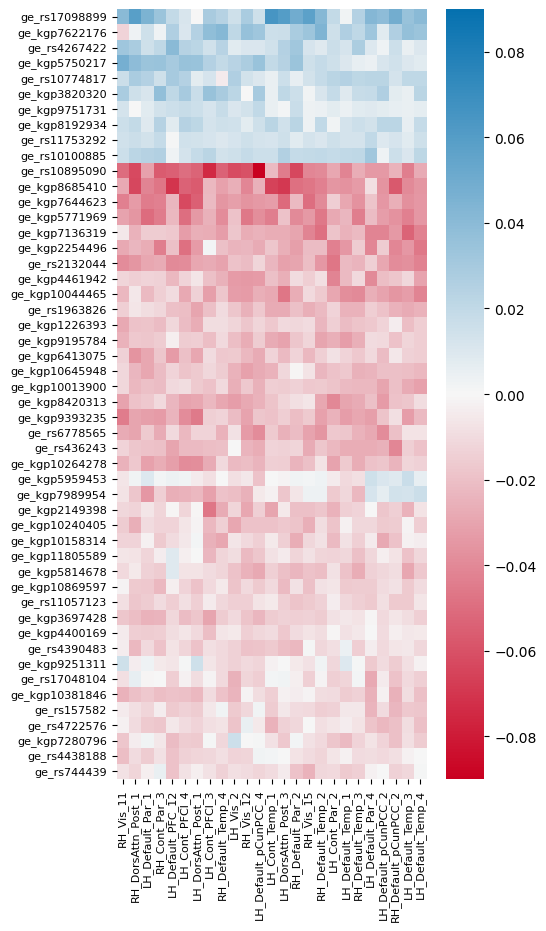

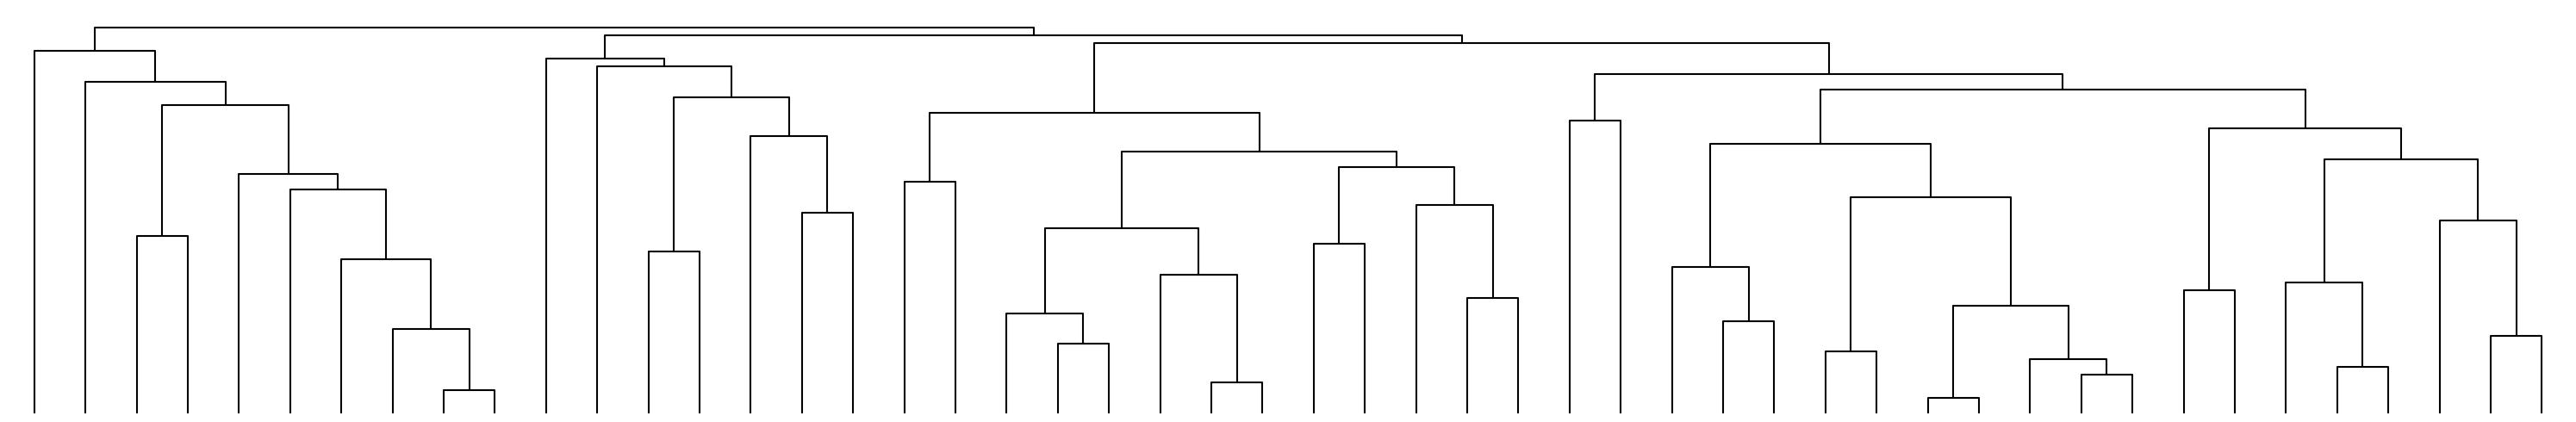

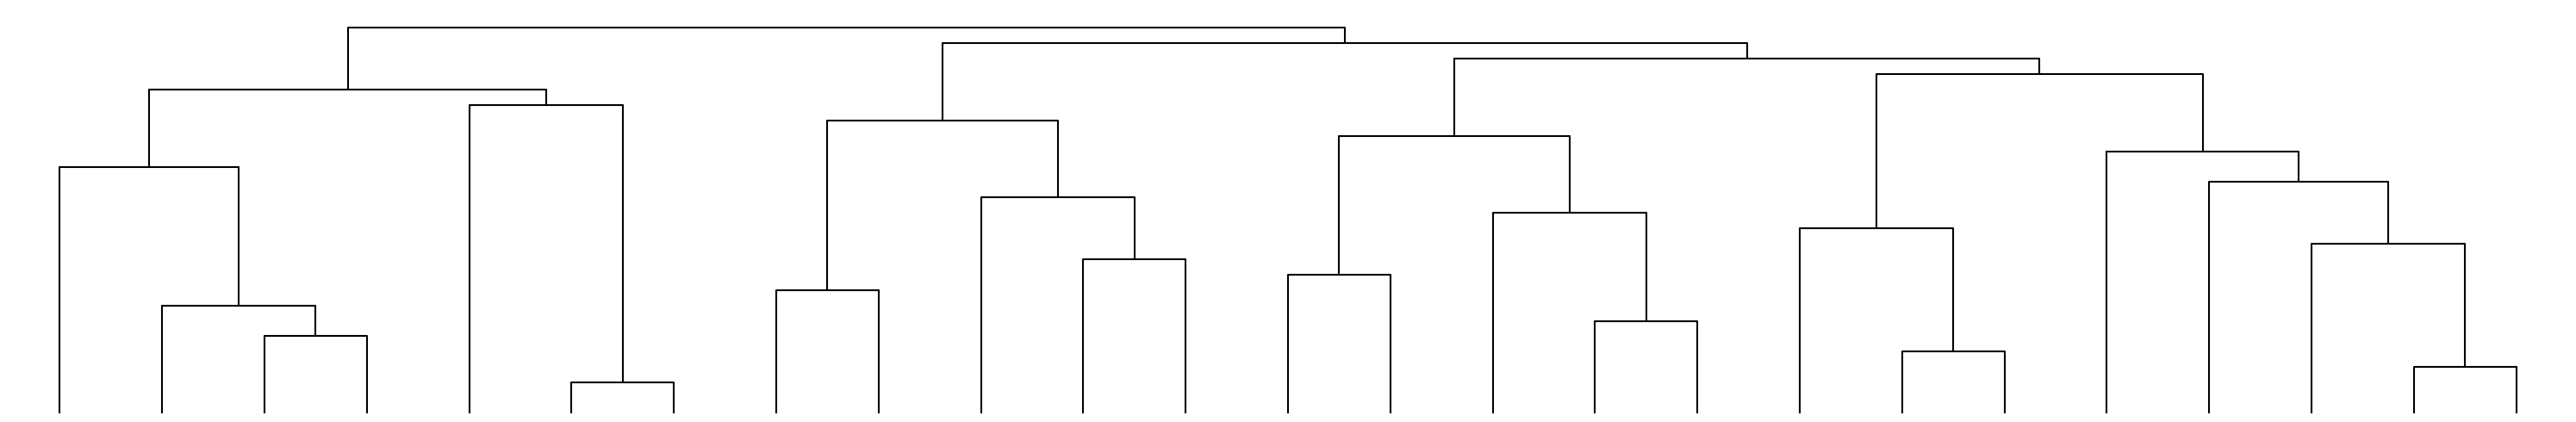

In [4]:
alpha_main = np.load("Results/alphamain.npy")
alpha_main = alpha_main[~np.all(alpha_main == 0, axis=1)]

gname = np.load("Results/genename.npy")
brname = np.load("Results/brainname.npy")

chose_g, chose_br = top_km_abs_sum_submatrix(
    alpha_main,
    k=50,
    m=25,
    g=True,
)

alpha_sort = top_km_abs_sum_submatrix(
    alpha_main,
    k=50,
    m=25,
)

row_perm, col_perm, row_model, col_model = agglom_leaf_permutations(
    alpha_sort,
    linkage="ward",
    metric="euclidean",
)

alpha = alpha_sort[row_perm][:, col_perm]

threshold = 0
mask = np.abs(alpha) < threshold

my_cmap = make_double_cmp(
    [RR, G],
    [RG, G],
    [RB, G],
    [BR, G],
    [BG, G],
    [BB, G],
)

plt.figure(figsize=(5, 10))
sns.heatmap(
    alpha,
    mask=mask,
    cmap=my_cmap,
    linewidths=0.0,
    cbar=True,
    vmax=0.09,
    vmin=-0.09,
)

ax = plt.gca()

ax.set_yticks(np.arange(alpha.shape[0]) + 0.5)
ax.set_yticklabels(gname[chose_g], rotation=0, fontsize=8)

ax.set_xticks(np.arange(alpha.shape[1]) + 0.5)
ax.set_xticklabels([name[6:] for name in brname[chose_br]], rotation=90, fontsize=8)

plt.title("")
plt.show()

Z = plot_sklearn_dendrogram_with_leaf_ids(
    row_model,
    orientation="top",
    leaf_font_size=15,
    name="",
)

Z = plot_sklearn_dendrogram_with_leaf_ids(
    col_model,
    orientation="top",
    leaf_font_size=15,
    name="",
)

### Brain - Outcome

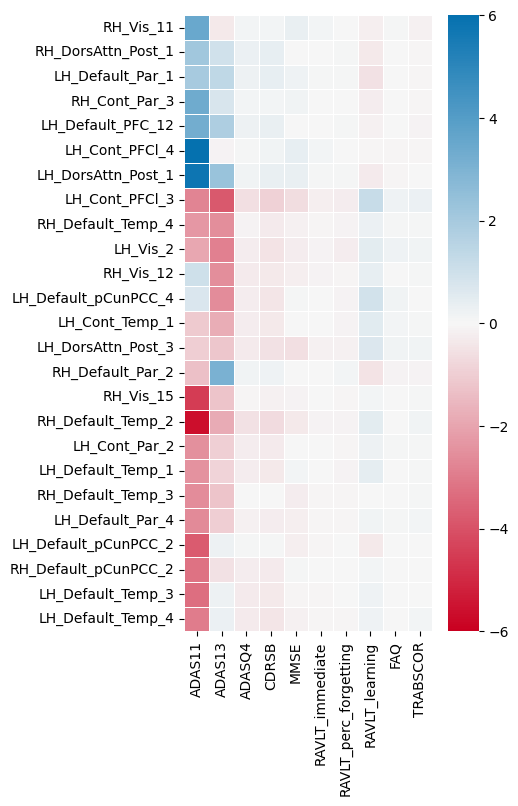

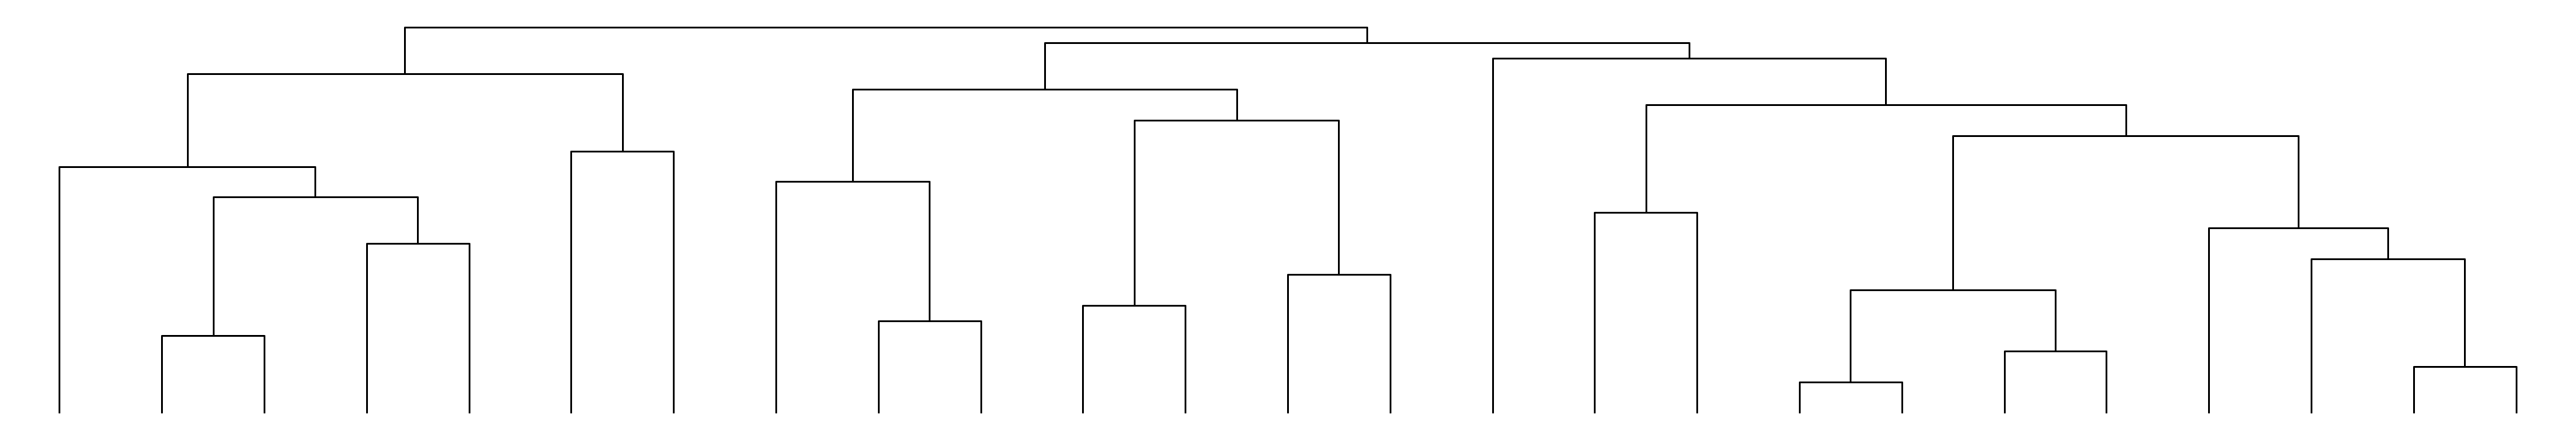

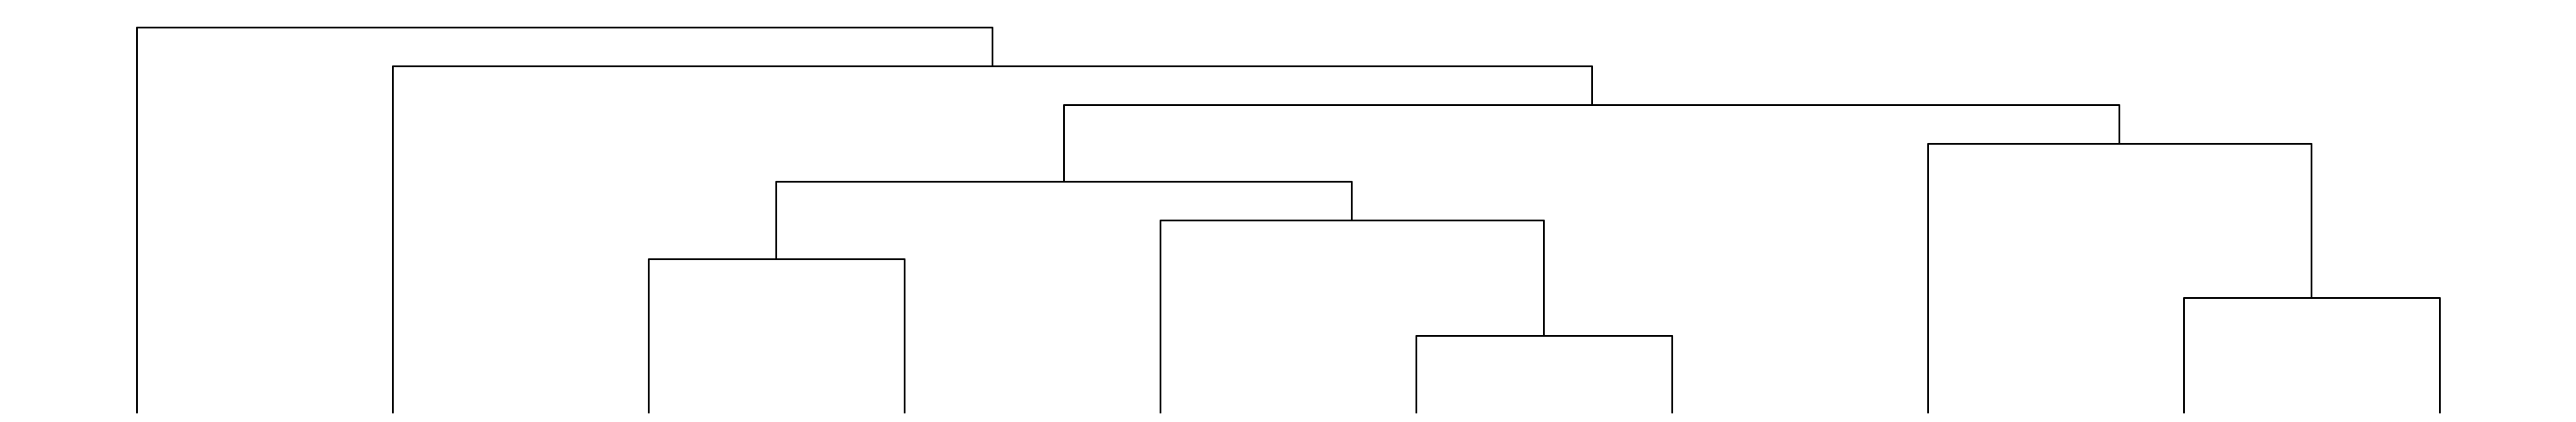

In [5]:
beta_sort = top_km_abs_sum_submatrix(
    np.load("Results/betamain.npy"),
    k=25,
    m=10,
)

row_perm, col_perm, row_model, col_model = agglom_leaf_permutations(
    beta_sort,
    linkage="ward",
    metric="euclidean",
)

beta = beta_sort[row_perm][:, col_perm]

threshold = 0
mask = np.abs(beta) < threshold

my_cmap = make_double_cmp(
    [RR, G],
    [RG, G],
    [RB, G],
    [BR, G],
    [BG, G],
    [BB, G],
)

outcome_names = [
    "ADAS11",
    "ADAS13",
    "ADASQ4",
    "CDRSB",
    "MMSE",
    "RAVLT_immediate",
    "RAVLT_perc_forgetting",
    "RAVLT_learning",
    "FAQ",
    "TRABSCOR",
]

plt.figure(figsize=(4, 8))
sns.heatmap(
    beta,
    mask=mask,
    cmap=my_cmap,
    fmt=".2f",
    linewidths=0.5,
    cbar=True,
    vmax=6,
    vmin=-6,
)

ax = plt.gca()

ax.set_yticks(np.arange(beta.shape[0]) + 0.5)
ax.set_yticklabels([name[6:] for name in brname[chose_br]], rotation=0)

ax.set_xticks(np.arange(beta.shape[1]) + 0.5)
ax.set_xticklabels(outcome_names, rotation=90)

plt.title("")
plt.show()

Z = plot_sklearn_dendrogram_with_leaf_ids(
    row_model,
    orientation="top",
    leaf_font_size=6,
    name="",
)

Z = plot_sklearn_dendrogram_with_leaf_ids(
    col_model,
    orientation="top",
    leaf_font_size=6,
    name="",
)

# The β map for studying brain regions related to different cognitive-behavior outcomes (5.3)

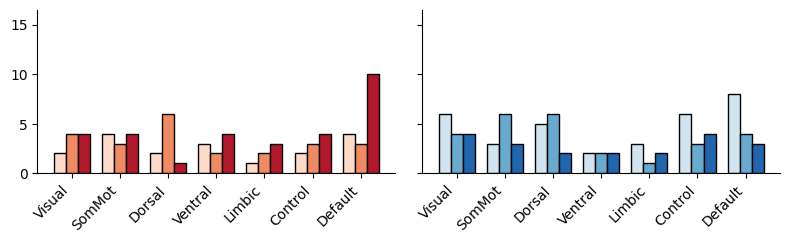

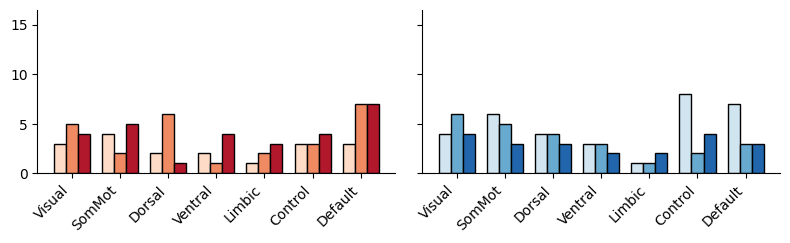

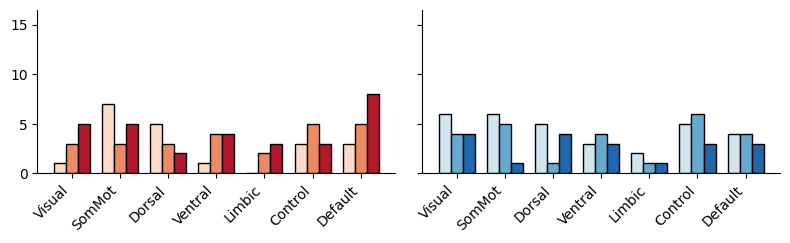

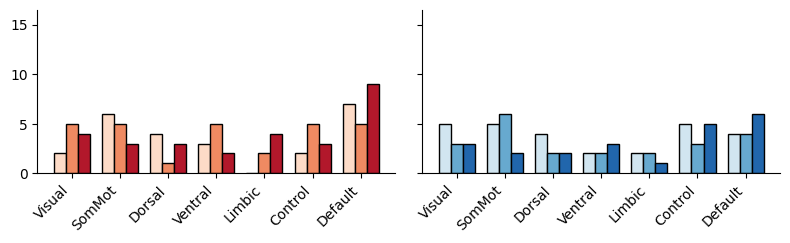

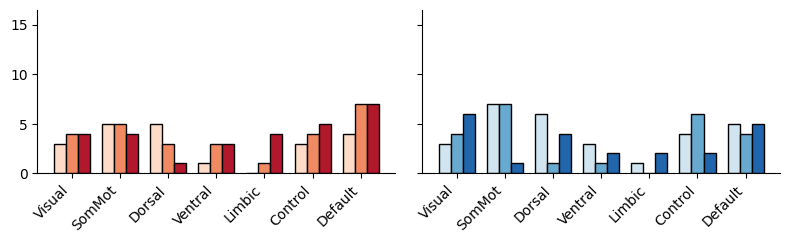

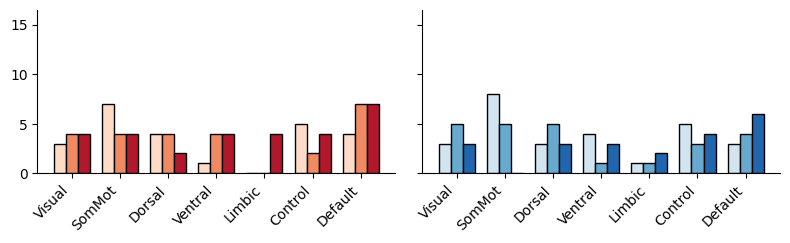

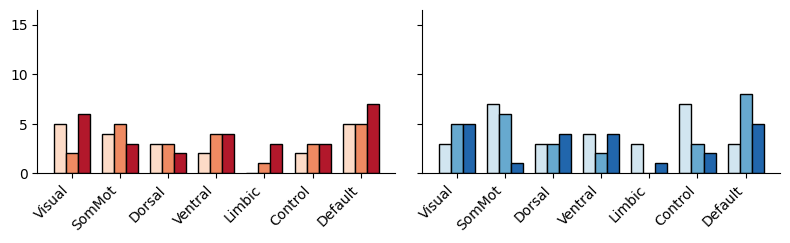

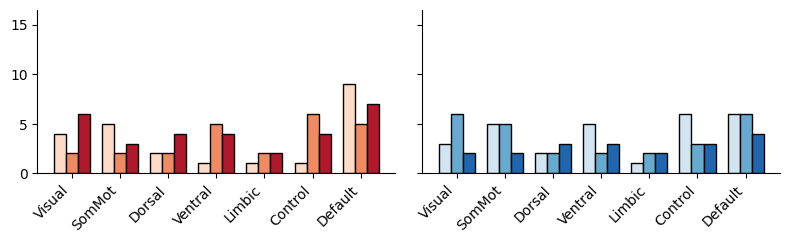

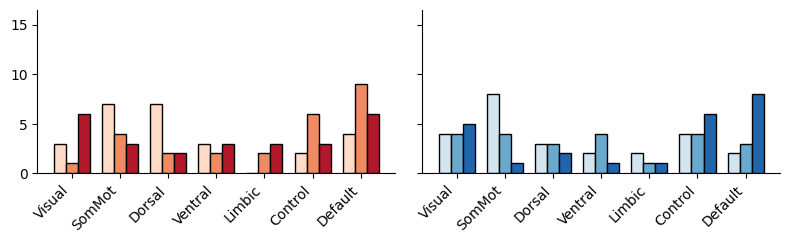

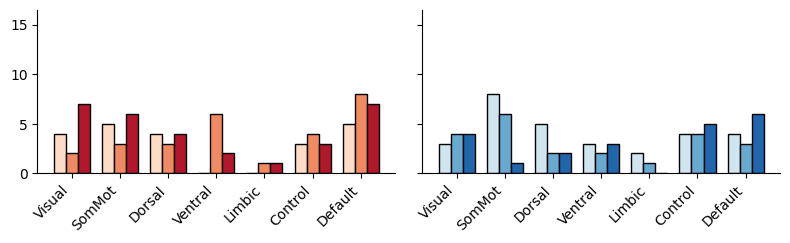

In [6]:
outcome_names = [
    "ADAS11",
    "ADAS13",
    "ADASQ4",
    "CDRSB",
    "MMSE",
    "RAVLT_immediate",
    "RAVLT_perc_forgetting",
    "RAVLT_learning",
    "FAQ",
    "TRABSCOR",
]

for outcome_name in outcome_names:
    plot_feature_importance_quantile(
        15,
        label=outcome_name,
        method=None,
    )

In [ ]:
# Code for generating the brain images is provided in the `brain_image` folder.

# The MMM genetic–brain–cognitive mediation effect (5.4)

In [ ]:
outcome_idx = [1, 3, 4, 5]

alpha_main = np.load("Results/alphamain.npy")
beta_main = np.load("Results/betamain.npy")

alpha_cells = top_k_abs_cells(alpha_main, k=50)
alpha_cells = [
    cell
    for idx, cell in enumerate(alpha_cells)
    if cell[0] not in [prev_cell[0] for prev_cell in alpha_cells[:idx]]
]

gene_idx = [int(cell[0]) for cell in alpha_cells[:6]]

beta_cells = top_k_abs_cells(beta_main[:, outcome_idx], k=100)
beta_cells = [
    cell
    for idx, cell in enumerate(beta_cells)
    if cell[0] not in [prev_cell[0] for prev_cell in beta_cells[:idx]]
]

br_idx = (
    [int(cell[1]) for cell in alpha_cells[:6]]
    + [int(cell[0]) for cell in beta_cells[:4]]
)[:9]

alpha = zero_smallest_25_percent(
    standard_scaler(alpha_main[np.ix_(gene_idx, br_idx)]),
    50,
)

beta = zero_smallest_25_percent(
    standard_scaler(beta_main[np.ix_(br_idx, outcome_idx)]),
    50,
)

np.savetxt("Results/Alpha_plot_Q2.csv", alpha, delimiter=",")
np.savetxt("Results/Beta_plot_Q2.csv", beta, delimiter=",")

In [ ]:
# The code for generating the Sankey diagram is provided in the accompanying R file.

# Multivariate outcome prediction in previously unseen subjects (5.5)

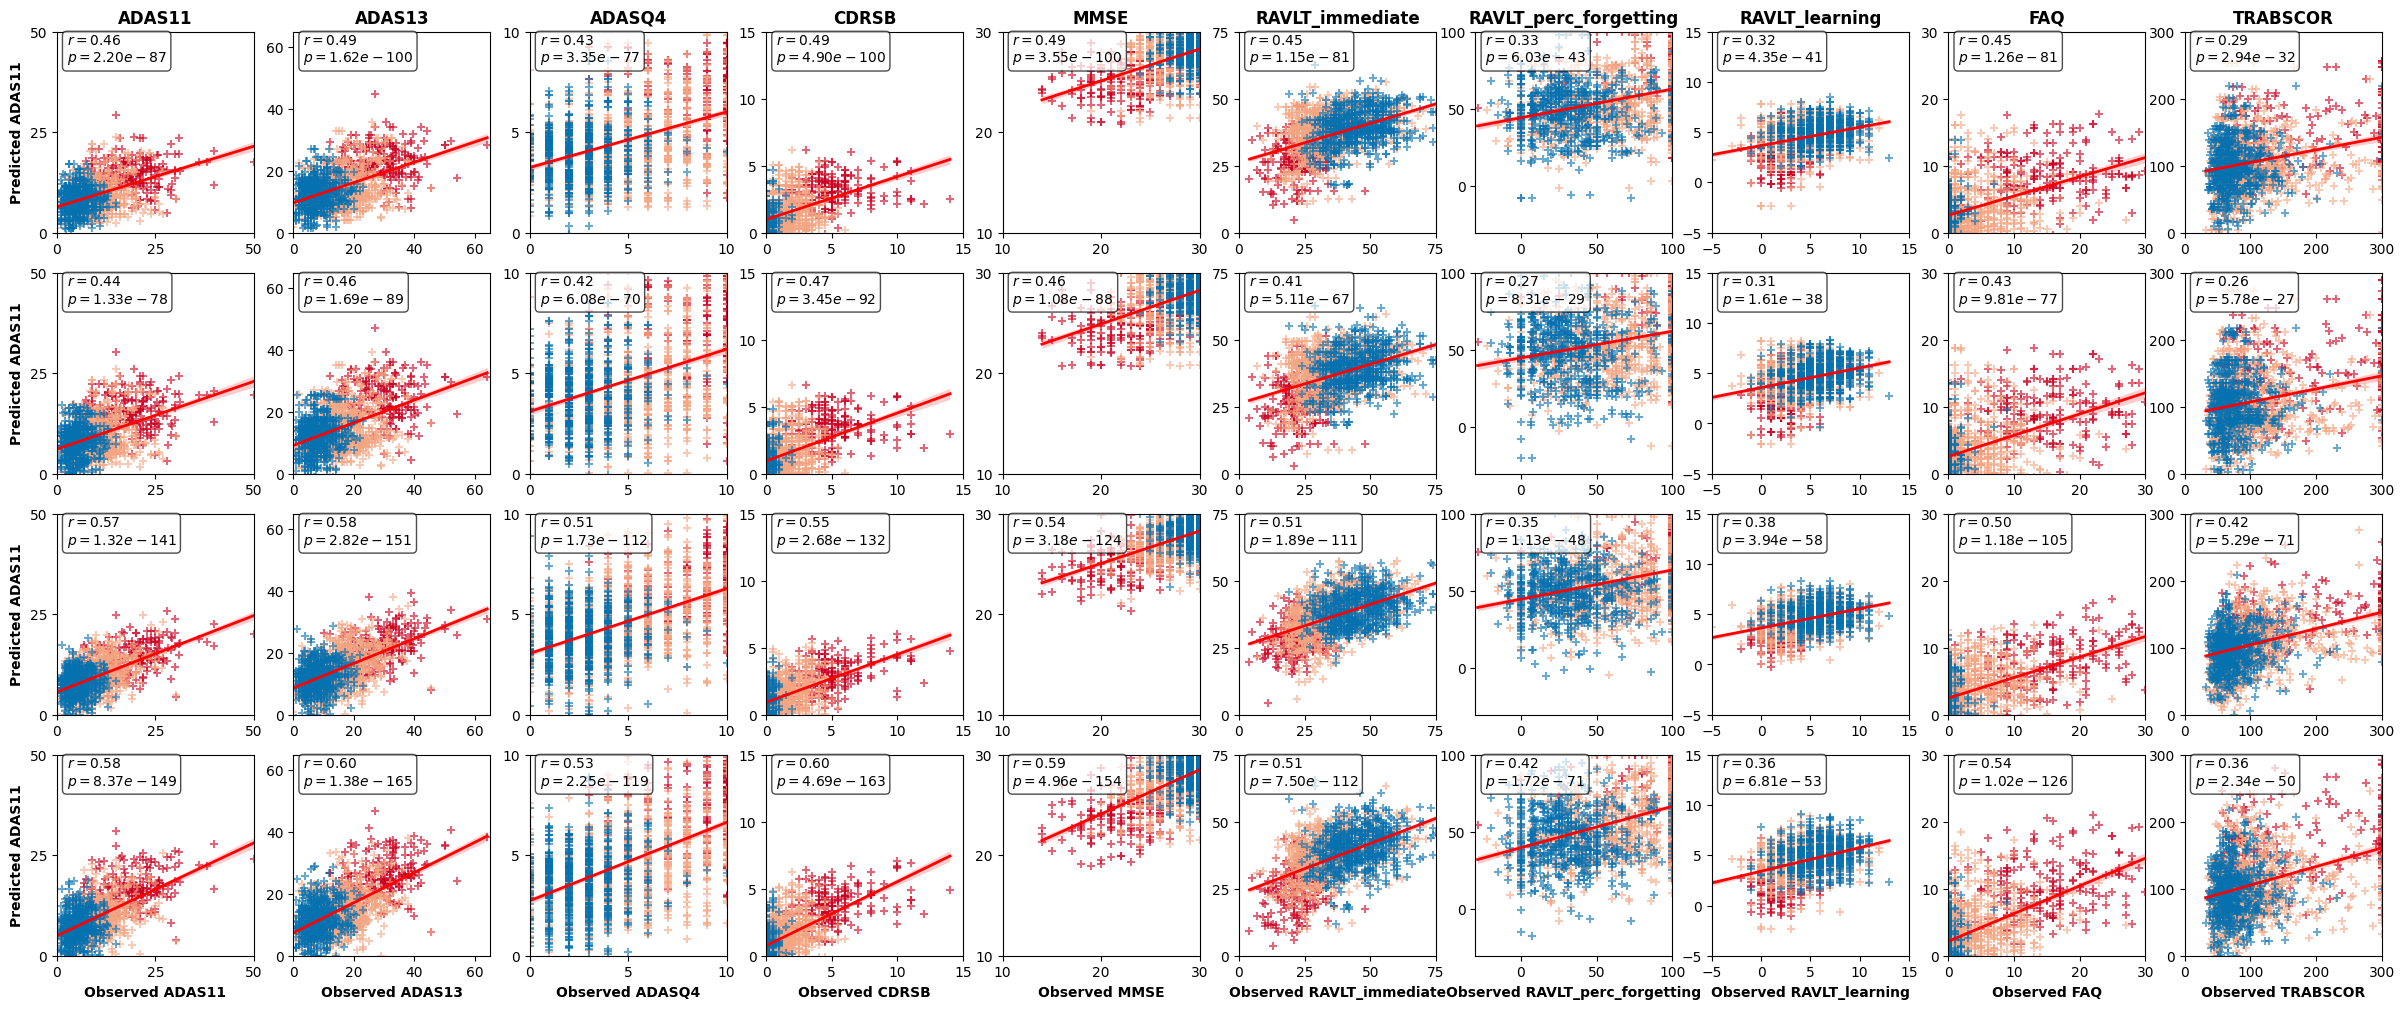

In [7]:
# Rows correspond to:
# 1) mediation approach,
# 2) prediction using only gene data,
# 3) prediction using only brain data,
# 4) prediction using both gene and brain data without mediation.


names = [
    "ADAS11",
    "ADAS13",
    "ADASQ4",
    "CDRSB",
    "MMSE",
    "RAVLT_immediate",
    "RAVLT_perc_forgetting",
    "RAVLT_learning",
    "FAQ",
    "TRABSCOR",
]

experiments = [
    (
        "Results/688genes_test.npy",
        "Results/688genes.npy",
        "Results/688genes_label.npy",
        "Mediation",
    ),
    (
        "Results/688genes_test_noM.npy",
        "Results/688genes_noM.npy",
        "Results/688genes_label_noM.npy",
        "Only_Gene",
    ),
    (
        "Results/688genes_test_noX.npy",
        "Results/688genes_noX.npy",
        "Results/688genes_label_noX.npy",
        "Only_Brain",
    ),
    (
        "Results/688genes_test_MandX.npy",
        "Results/688genes_MandX.npy",
        "Results/688genes_label_MandX.npy",
        "Gene_and_Brain",
    ),
]

COL_AD = "#ca0020"
COL_MCI = "#f4a582"
COL_CN = "#0571b0"

AXIS_CFG = {
    "ADAS11": {"xlim": (0, 50), "ylim": (0, 50), "x": [0, 25, 50], "y": [0, 25, 50]},
    "ADAS13": {"xlim": (0, 65), "ylim": (0, 65), "x": [0, 20, 40, 60], "y": [0, 20, 40, 60]},
    "ADASQ4": {"xlim": (0, 10), "ylim": (0, 10), "x": [0, 5, 10], "y": [0, 5, 10]},
    "CDRSB": {"xlim": (0, 15), "ylim": (0, 15), "x": [0, 5, 10, 15], "y": [0, 5, 10, 15]},
    "MMSE": {"xlim": (10, 30), "ylim": (10, 30), "x": [10, 20, 30], "y": [10, 20, 30]},
    "RAVLT_immediate": {"xlim": (0, 75), "ylim": (0, 75), "x": [0, 25, 50, 75], "y": [0, 25, 50, 75]},
    "RAVLT_perc_forgetting": {"xlim": (-30, 100), "ylim": (-30, 100), "x": [0, 50, 100], "y": [0, 50, 100]},
    "RAVLT_learning": {"xlim": (-5, 15), "ylim": (-5, 15), "x": [-5, 0, 5, 10, 15], "y": [-5, 0, 5, 10, 15]},
    "FAQ": {"xlim": (0, 30), "ylim": (0, 30), "x": [0, 10, 20, 30], "y": [0, 10, 20, 30]},
    "TRABSCOR": {"xlim": (0, 300), "ylim": (0, 300), "x": [0, 100, 200, 300], "y": [0, 100, 200, 300]},
}

MARKER_STYLE = dict(
    marker="+",
    s=35,
    alpha=0.6,
)

n_rows = len(experiments)
n_cols = len(names)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (obs_file, pred_file, label_file, row_title) in enumerate(experiments):
    matrix1 = np.array(np.load(obs_file, allow_pickle=True), dtype=float)
    matrix2 = np.array(np.load(pred_file), dtype=float)
    label = np.load(label_file, allow_pickle=True)

    mmse_col = names.index("MMSE")
    matrix1[:, mmse_col] = np.minimum(matrix1[:, mmse_col], 30.0)
    matrix2[:, mmse_col] = np.minimum(matrix2[:, mmse_col], 30.0)

    rfor_col = names.index("RAVLT_perc_forgetting")
    matrix1[:, rfor_col] = np.minimum(matrix1[:, rfor_col], 100.0)
    matrix2[:, rfor_col] = np.minimum(matrix2[:, rfor_col], 100.0)

    full_mci = label == "MCI"
    full_cn = label == "CN"
    full_ad = label == "AD"

    for col, name in enumerate(names):
        ax = axes[row, col]

        x_full = matrix1[:, col]
        y_full = matrix2[:, col]

        mask = np.ones_like(x_full, dtype=bool)

        if name == "RAVLT_perc_forgetting":
            outlier_idx = np.argsort(x_full)[:3]
            mask[outlier_idx] = False

        if name == "TRABSCOR":
            outlier_idx = np.argsort(x_full)[:3]
            mask[outlier_idx] = False

        if name == "MMSE":
            outlier_idx = np.argsort(x_full)[:1]
            mask[outlier_idx] = False

        x = x_full[mask]
        y = y_full[mask]

        mci_mask = full_mci & mask
        cn_mask = full_cn & mask
        ad_mask = full_ad & mask

        slope, intercept = np.polyfit(x, y, 1)
        r_value = np.corrcoef(x, y)[0, 1]
        _, p_value = stats.pearsonr(x, y)

        x_grid = np.linspace(x.min(), x.max(), 200)
        y_grid = slope * x_grid + intercept

        alpha = 0.05
        n = len(x)
        x_mean = np.mean(x)

        y_hat = slope * x + intercept
        s_err = np.sqrt(np.sum((y - y_hat) ** 2) / (n - 2))
        t_val = stats.t.ppf(1 - alpha / 2, df=n - 2)

        ci_grid = t_val * s_err * np.sqrt(
            1 / n + (x_grid - x_mean) ** 2 / np.sum((x - x_mean) ** 2)
        )

        lower = y_grid - ci_grid
        upper = y_grid + ci_grid

        ax.fill_between(x_grid, lower, upper, color="red", alpha=0.2, linewidth=0)
        ax.plot(x_grid, y_grid, linewidth=2, color="red")

        ax.scatter(x_full[ad_mask], y_full[ad_mask], color=COL_AD, **MARKER_STYLE)
        ax.scatter(x_full[mci_mask], y_full[mci_mask], color=COL_MCI, **MARKER_STYLE)
        ax.scatter(x_full[cn_mask], y_full[cn_mask], color=COL_CN, **MARKER_STYLE)

        cfg = AXIS_CFG.get(name, {})

        if "xlim" in cfg:
            ax.set_xlim(cfg["xlim"])
        else:
            ax.set_xlim(x.min(), x.max())

        if "ylim" in cfg:
            ax.set_ylim(cfg["ylim"])
        else:
            ax.set_ylim(y.min(), y.max())

        if "x" in cfg:
            ax.set_xticks(cfg["x"])

        if "y" in cfg:
            ax.set_yticks(cfg["y"])

        text_str = f"$r = {r_value:.2f}$\n$p = {p_value:.2e}$"
        ax.text(
            0.05,
            0.85,
            text_str,
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                edgecolor="black",
                boxstyle="round,pad=0.3",
            ),
        )

        if row == 0:
            ax.set_title(name, fontsize=12, fontweight="bold")

        if row == n_rows - 1:
            ax.set_xlabel(f"Observed {name}", fontweight="bold", fontsize=10)
        else:
            ax.set_xlabel("")

        if col == 0:
            ax.set_ylabel(f"Predicted {name}", fontweight="bold", fontsize=10)
        else:
            ax.set_ylabel("")

plt.show()

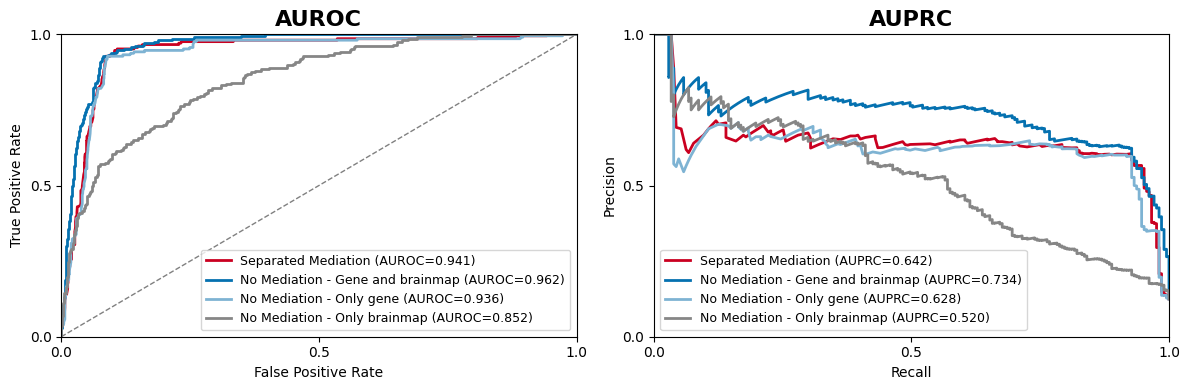

In [8]:
def rgb255(r, g, b):
    """
    Convert RGB values from the 0--255 scale to the 0--1 scale.

    Parameters
    ----------
    r : int or float
        Red channel.
    g : int or float
        Green channel.
    b : int or float
        Blue channel.

    Returns
    -------
    tuple
        RGB tuple normalized to the 0--1 scale.
    """
    return (r / 255.0, g / 255.0, b / 255.0)


RR = 202
RG = 0
RB = 32

BR = 5
BG = 113
BB = 176

true_sep = np.load("Results/688genes_test_dis.npy", allow_pickle=True)
pred_sep = np.load("Results/688gene_dis.npy", allow_pickle=True)

true_nb_gb = np.load("Results/688genes_test_dis_MandX.npy", allow_pickle=True)
pred_nb_gb = np.load("Results/688gene_dis_MandX.npy", allow_pickle=True)

true_nb_gene = np.load("Results/688genes_test_dis_noM.npy", allow_pickle=True)
pred_nb_gene = np.load("Results/688gene_dis_noM.npy", allow_pickle=True)

true_nb_brain = np.load("Results/688genes_test_dis_noX.npy", allow_pickle=True)
pred_nb_brain = np.load("Results/688gene_dis_noX.npy", allow_pickle=True)

models = {
    "Separated Mediation": (true_sep, pred_sep),
    "No Mediation - Gene and brainmap": (true_nb_gb, pred_nb_gb),
    "No Mediation - Only gene": (true_nb_gene, pred_nb_gene),
    "No Mediation - Only brainmap": (true_nb_brain, pred_nb_brain),
}

model_colors = {
    "Separated Mediation": rgb255(RR, RG, RB),
    "No Mediation - Gene and brainmap": rgb255(BR, BG, BB),
    "No Mediation - Only gene": make_cmp(
        [BR, G],
        [BG, G],
        [BB, G],
        N=3,
    )(np.linspace(0, 1, 3)[1]),
    "No Mediation - Only brainmap": rgb255(134, 134, 134),
}

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 4))

for name, (true_mat, pred_mat) in models.items():
    color = model_colors[name]

    y_true = np.asarray(true_mat, dtype=float).ravel()
    y_score = np.asarray(pred_mat, dtype=float).ravel()

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auroc, auprc = compute_auc_scores(true_mat, pred_mat)

    ax_roc.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{name} (AUROC={auroc:.3f})",
    )

    precision, recall, _ = precision_recall_curve(y_true, y_score)

    ax_pr.plot(
        recall,
        precision,
        color=color,
        linewidth=2,
        label=f"{name} (AUPRC={auprc:.3f})",
    )

ax_roc.plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("AUROC", fontsize=16, fontweight="bold")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1)
ax_roc.set_xticks([0, 0.5, 1])
ax_roc.set_yticks([0, 0.5, 1])
ax_roc.legend(loc="lower right", fontsize=9)

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("AUPRC", fontsize=16, fontweight="bold")
ax_pr.set_xlim(0, 1)
ax_pr.set_ylim(0, 1)
ax_pr.set_xticks([0, 0.5, 1])
ax_pr.set_yticks([0, 0.5, 1])
ax_pr.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()